In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

print(torch.__version__)

2.6.0+cu124


# Step 2: Load and Preprocess the Data

In [20]:
# Data transformation (normalization)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

# Download CIFAR-10 Dataset
transet= torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(transet, batch_size=16, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=16, shuffle=False)

# Class labels
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Visualize Sample Data

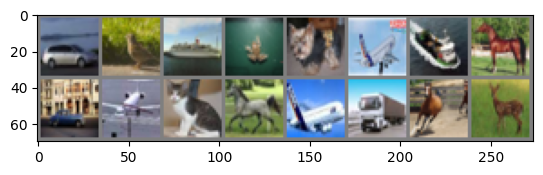

car bird ship frog dog plane ship horse


In [21]:
# Function to display images
def imshow(img):
    img = img / 2 + 0.5
    plt.imshow(np.transpose(img.numpy(), (1,2,0)))

# Get a batch of training data
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show images
imshow(torchvision.utils.make_grid(images))
plt.show()

# Display Labels
print(' '.join(f'{classes[labels[j]]}' for j in range(8)))

In [22]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(64*8*8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(-1, 64*8*8)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

# Step 5 Model Training Setup

In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'using device: {device}')

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer =optim.Adam(model.parameters(), lr=0.001)

using device: cuda


# Step 6: Train the Model

In [24]:
# Training loop
num_epochs = 5
for epoch in range(num_epochs):
    running_loss = 0.0
    for i, (inputs,labels) in enumerate(trainloader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Reset Gradients
        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, labels) # Compute Loss
        loss.backward() # Backward pass
        optimizer.step() # Update weights

        running_loss += loss.item()
        if i % 100 == 99:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(trainloader)}], Loss: {running_loss/100:.4f}')

print('Finished Training')

Epoch [1/5], Step [100/3125], Loss: 2.0290
Epoch [1/5], Step [200/3125], Loss: 3.8000
Epoch [1/5], Step [300/3125], Loss: 5.4158
Epoch [1/5], Step [400/3125], Loss: 6.9750
Epoch [1/5], Step [500/3125], Loss: 8.4686
Epoch [1/5], Step [600/3125], Loss: 9.9096
Epoch [1/5], Step [700/3125], Loss: 11.2726
Epoch [1/5], Step [800/3125], Loss: 12.5970
Epoch [1/5], Step [900/3125], Loss: 13.9167
Epoch [1/5], Step [1000/3125], Loss: 15.1918
Epoch [1/5], Step [1100/3125], Loss: 16.3910
Epoch [1/5], Step [1200/3125], Loss: 17.6548
Epoch [1/5], Step [1300/3125], Loss: 18.9119
Epoch [1/5], Step [1400/3125], Loss: 20.1540
Epoch [1/5], Step [1500/3125], Loss: 21.3500
Epoch [1/5], Step [1600/3125], Loss: 22.4852
Epoch [1/5], Step [1700/3125], Loss: 23.6251
Epoch [1/5], Step [1800/3125], Loss: 24.7435
Epoch [1/5], Step [1900/3125], Loss: 25.8689
Epoch [1/5], Step [2000/3125], Loss: 26.9928
Epoch [1/5], Step [2100/3125], Loss: 28.0932
Epoch [1/5], Step [2200/3125], Loss: 29.1957
Epoch [1/5], Step [2300/3

# Step 7: Evaluate the Model

In [25]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy on test data: {100 * correct / total:.2f}%')

Accuracy on test data: 71.22%


Predicted:  cat car ship plane frog frog car frog
Actual:    cat ship ship plane frog frog car frog


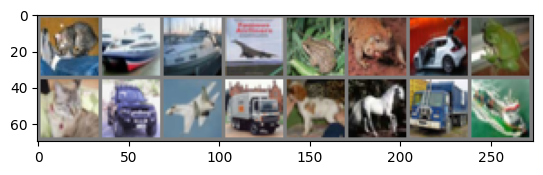

In [27]:
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, predicted = torch.max(outputs, 1)

imshow(torchvision.utils.make_grid(images.cpu()))
print('Predicted: ', ' '.join(f'{classes[predicted[j]]}' for j in range(8)))
print('Actual:   ', ' '.join(f'{classes[labels[j]]}' for j in range(8)))